# Modelos de clasificación multiclase con ingeniería de características

## Instrucciones

En este cuaderno se deben entrenar los mismos modelos trabajados en el notebook Modelos_NO_FE.ipynb:

- Perceptrón
- Regresión Logística
- Árbol de Decisión

Se debe mantener el mismo valor de random_state = 7833.

Como parte de la ingeniería de características, se aplicará MinMaxScaler a las columnas cuyos rangos de valores son considerablemente mayores que los del resto de variables. En este caso se escalarán las siguientes columnas:

- Area
- Perimeter
- MajorAxisLength
- MinorAxisLength
- ConvexArea
- EquivDiameter

La decisión se toma porque estas variables presentan magnitudes mucho más grandes que otras columnas del dataset, mientras que variables como Eccentricity, Extent, Solidity, Compactness y ShapeFactor ya se encuentran en escalas pequeñas o cercanas al intervalo [0, 1].

Todo lo demás seguirá el mismo flujo trabajado en el notebook Modelos_NO_FE.ipynb.

## Importación de librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

## Carga de los conjuntos de entrenamiento y prueba

In [2]:
train_df = pd.read_csv("data/processed/train.csv")
test_df = pd.read_csv("data/processed/test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (10888, 17)
Test shape: (2723, 17)


In [3]:
X_train = train_df.drop(columns=["Class"])
y_train = train_df["Class"]

X_test = test_df.drop(columns=["Class"])
y_test = test_df["Class"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (10888, 16)
X_test: (2723, 16)
y_train: (10888,)
y_test: (2723,)


## Ingeniería de características con MinMaxScaler

### Selección de columnas a escalar

In [4]:
columns_to_scale = [
    "Area",
    "Perimeter",
    "MajorAxisLength",
    "MinorAxisLength",
    "ConvexArea",
    "EquivDiameter"
]

columns_to_scale

['Area',
 'Perimeter',
 'MajorAxisLength',
 'MinorAxisLength',
 'ConvexArea',
 'EquivDiameter']

### Aplicación de MinMaxScaler

In [5]:
scaler = MinMaxScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test_scaled[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

print("Escalamiento aplicado correctamente.")

Escalamiento aplicado correctamente.


## Verificación rápida del resultado del escalamiento

In [6]:
X_train_scaled[columns_to_scale].describe().loc[["min", "max"]]

,Area,Perimeter,MajorAxisLength,MinorAxisLength,ConvexArea,EquivDiameter
min,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0


## Modelo Perceptrón

### Entrenamiento del modelo Perceptrón

In [7]:
perceptron_model = Perceptron(random_state=7833)

perceptron_model.fit(X_train_scaled, y_train)

y_pred_perceptron = perceptron_model.predict(X_test_scaled)

perceptron_model

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",7833


### Evaluación del modelo Perceptrón

In [8]:
accuracy_perceptron = accuracy_score(y_test, y_pred_perceptron)
f1_perceptron = f1_score(y_test, y_pred_perceptron, average="macro")

print("Accuracy:", accuracy_perceptron)
print("F1 Macro:", f1_perceptron)

Accuracy: 0.7726771942710247
F1 Macro: 0.8029799558027787


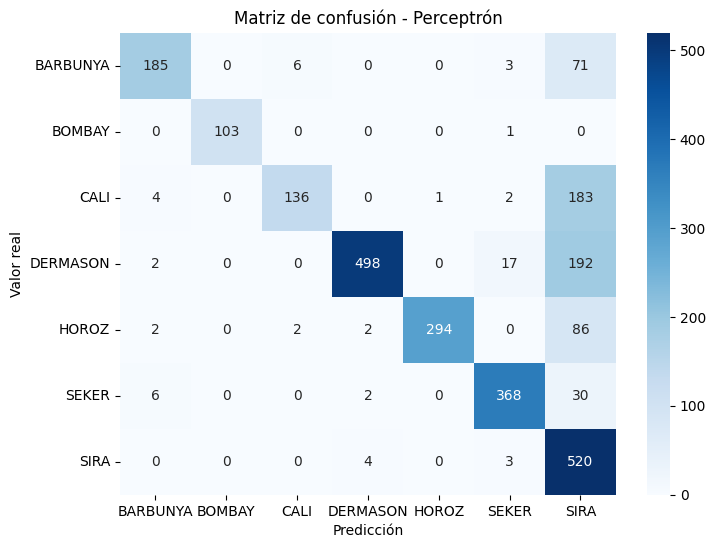

In [9]:
cm_perceptron = confusion_matrix(y_test, y_pred_perceptron, labels=perceptron_model.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_perceptron,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=perceptron_model.classes_,
    yticklabels=perceptron_model.classes_
)
plt.title("Matriz de confusión - Perceptrón")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [10]:
print(classification_report(y_test, y_pred_perceptron, zero_division=0))

              precision    recall  f1-score   support

    BARBUNYA       0.93      0.70      0.80       265
      BOMBAY       1.00      0.99      1.00       104
        CALI       0.94      0.42      0.58       326
    DERMASON       0.98      0.70      0.82       709
       HOROZ       1.00      0.76      0.86       386
       SEKER       0.93      0.91      0.92       406
        SIRA       0.48      0.99      0.65       527

    accuracy                           0.77      2723
   macro avg       0.90      0.78      0.80      2723
weighted avg       0.87      0.77      0.78      2723



## Modelo Regresión Logística

### Entrenamiento del modelo Regresión Logística

In [11]:
logreg_model = LogisticRegression(max_iter=10000, random_state=7833)

logreg_model.fit(X_train_scaled, y_train)

y_pred_logreg = logreg_model.predict(X_test_scaled)

### Evaluación del modelo Regresión Logística

In [12]:
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg, average="macro")

print("Accuracy:", accuracy_logreg)
print("F1 Macro:", f1_logreg)

Accuracy: 0.9048843187660668
F1 Macro: 0.9141793524620373


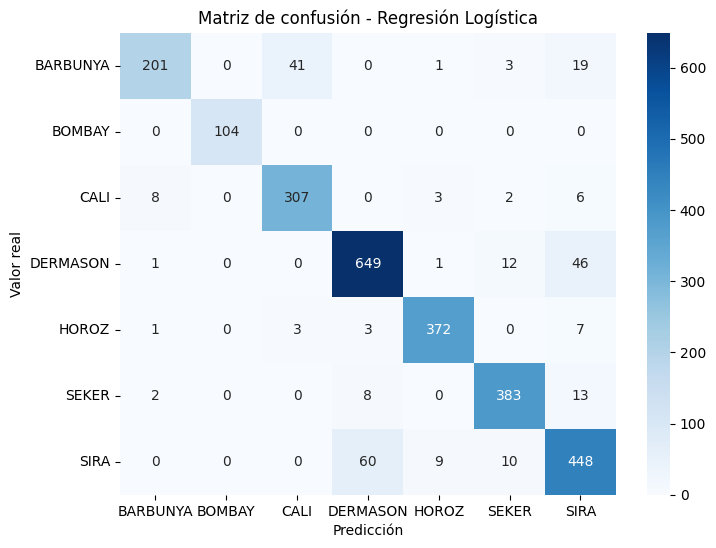

In [13]:
cm_logreg = confusion_matrix(y_test, y_pred_logreg, labels=logreg_model.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_logreg,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=logreg_model.classes_,
    yticklabels=logreg_model.classes_
)
plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [14]:
print(classification_report(y_test, y_pred_logreg, zero_division=0))

              precision    recall  f1-score   support

    BARBUNYA       0.94      0.76      0.84       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.87      0.94      0.91       326
    DERMASON       0.90      0.92      0.91       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.93      0.94      0.94       406
        SIRA       0.83      0.85      0.84       527

    accuracy                           0.90      2723
   macro avg       0.92      0.91      0.91      2723
weighted avg       0.91      0.90      0.90      2723



## Modelo Árbol de Decisión

### Entrenamiento del modelo Árbol de Decisión

In [15]:
tree_model = DecisionTreeClassifier(random_state=7833)

tree_model.fit(X_train_scaled, y_train)

y_pred_tree = tree_model.predict(X_test_scaled)

### Evaluación del modelo Árbol de Decisión

In [16]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree, average="macro")

print("Accuracy:", accuracy_tree)
print("F1 Macro:", f1_tree)

Accuracy: 0.8979067205288285
F1 Macro: 0.9121093736828537


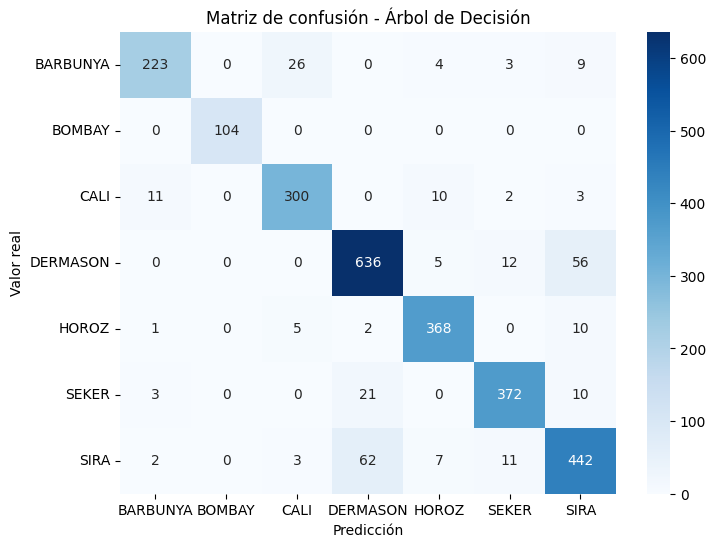

In [17]:
cm_tree = confusion_matrix(y_test, y_pred_tree, labels=tree_model.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=tree_model.classes_,
    yticklabels=tree_model.classes_
)
plt.title("Matriz de confusión - Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [18]:
print(classification_report(y_test, y_pred_tree, zero_division=0))

              precision    recall  f1-score   support

    BARBUNYA       0.93      0.84      0.88       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.90      0.92      0.91       326
    DERMASON       0.88      0.90      0.89       709
       HOROZ       0.93      0.95      0.94       386
       SEKER       0.93      0.92      0.92       406
        SIRA       0.83      0.84      0.84       527

    accuracy                           0.90      2723
   macro avg       0.92      0.91      0.91      2723
weighted avg       0.90      0.90      0.90      2723



## Comparación de métricas de los tres modelos

In [19]:
results_df = pd.DataFrame({
    "Modelo": ["Perceptrón", "Regresión Logística", "Árbol de Decisión"],
    "Accuracy": [accuracy_perceptron, accuracy_logreg, accuracy_tree],
    "F1 Macro": [f1_perceptron, f1_logreg, f1_tree]
})

results_df

,Modelo,Accuracy,F1 Macro
0,Perceptrón,0.772677,0.802980
1,Regresión Logística,0.904884,0.914179
2,Árbol de Decisión,0.897907,0.912109


## Visualización comparativa de métricas

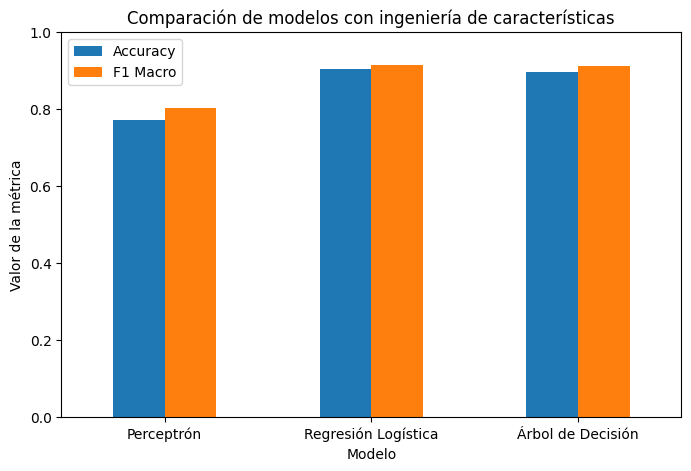

In [20]:
results_plot = results_df.set_index("Modelo")

results_plot.plot(kind="bar", figsize=(8, 5))
plt.title("Comparación de modelos con ingeniería de características")
plt.ylabel("Valor de la métrica")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

## Selección del mejor modelo

In [21]:
best_accuracy_model = results_df.loc[results_df["Accuracy"].idxmax(), "Modelo"]
best_f1_model = results_df.loc[results_df["F1 Macro"].idxmax(), "Modelo"]

print("Modelo con mejor Accuracy:", best_accuracy_model)
print("Modelo con mejor F1 Macro:", best_f1_model)

Modelo con mejor Accuracy: Regresión Logística
Modelo con mejor F1 Macro: Regresión Logística
